# Multinomial Naive Bayes

---

**Structure**
1. Introduction
2. The Math
3. Problem Class
4. Implementation — applied to the 20 Newsgroups dataset
5. Results
6. Limitations

## 1. Introduction

**Multinomial Naive Bayes** is a generative classifier for text. It models each document as a bag of words — a collection of word counts, ignoring word order — and learns the probability that each word appears given each class.

**Intuition:** to classify a news article, ask: how likely is it that this particular sequence of words would appear in a Sports article? In a Politics article? In a Technology article? Whichever class makes the observed words most probable wins.

The **naive** assumption is that each word's occurrence is independent of every other word given the class label. This is obviously false in reality — words like "machine" and "learning" tend to appear together — but despite this simplification the model works surprisingly well in practice, especially for text classification with many features.

**Why it is called generative:** the model learns $P(\text{word} | \text{class})$ for every word-class pair. Given a class, you could theoretically generate a document by sampling words from that distribution. Classification then uses Bayes' rule to invert this: given the document, which class is most likely?

## 2. The Math

### Likelihood of a document
Given a document $D$ with word counts $\text{count}(w)$ and class parameters $\theta^+$ (per-word probabilities):

$$P(D|\theta) = \prod_{w \in W} \theta_w^{\text{count}(w)}$$

### Maximum Likelihood Estimate
$$\hat{\theta}_w = \frac{\text{count}(w)}{\sum_{w' \in W} \text{count}(w')}$$

### Classification via Bayes rule
$$\log \frac{P(y=+|D)}{P(y=-|D)} = \sum_{w \in W} \text{count}(w) \cdot \log \frac{\theta_w^+}{\theta_w^-} + \log \frac{P(y=+)}{P(y=-)}$$

This is a **linear classifier** in word count space — each word has a weight $\tilde{\theta}_w = \log(\theta_w^+ / \theta_w^-)$.

### Laplace Smoothing
To handle words that never appear in a class (which would give $\theta_w = 0$ and $\log(0) = -\infty$):

$$\hat{\theta}_w = \frac{\text{count}(w) + \alpha}{\sum_{w'} \text{count}(w') + \alpha |W|}$$

where $\alpha = 1$ is the standard Laplace (add-one) smoothing.

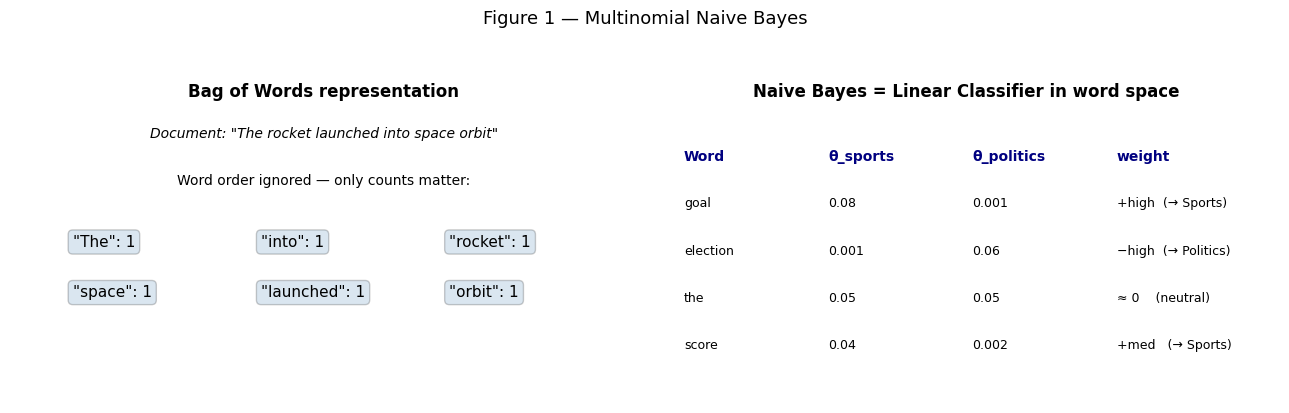

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Diagram 1: Bag of Words ───────────────────────────────────────────────────
ax = axes[0]
ax.axis('off')
doc = "The rocket launched into space orbit"
words = doc.split()
word_counts = {w: words.count(w) for w in set(words)}
ax.text(0.5, 0.95, 'Bag of Words representation', ha='center', va='top',
        fontsize=12, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.82, f'Document: "{doc}"', ha='center', va='top',
        fontsize=10, style='italic', transform=ax.transAxes)
ax.text(0.5, 0.68, 'Word order ignored — only counts matter:', ha='center', va='top',
        fontsize=10, transform=ax.transAxes)
for k, (word, count) in enumerate(word_counts.items()):
    col = k % 3
    row = k // 3
    ax.text(0.1 + col*0.3, 0.5 - row*0.15, f'"{word}": {count}',
            ha='left', va='top', fontsize=11, transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='steelblue', alpha=0.2))

# ── Diagram 2: Naive Bayes as linear classifier ───────────────────────────────
ax = axes[1]
ax.axis('off')
ax.text(0.5, 0.95, 'Naive Bayes = Linear Classifier in word space', ha='center',
        va='top', fontsize=12, fontweight='bold', transform=ax.transAxes)
rows = [
    ('Word', 'θ_sports', 'θ_politics', 'weight'),
    ('goal',   '0.08',    '0.001',    '+high  (→ Sports)'),
    ('election','0.001',  '0.06',     '−high  (→ Politics)'),
    ('the',    '0.05',    '0.05',     '≈ 0    (neutral)'),
    ('score',  '0.04',    '0.002',    '+med   (→ Sports)'),
]
for i, row in enumerate(rows):
    bold = (i == 0)
    for j, val in enumerate(row):
        ax.text(0.05+j*0.23, 0.75-i*0.14, val, ha='left', va='top',
                fontsize=9 if not bold else 10,
                fontweight='bold' if bold else 'normal',
                transform=ax.transAxes,
                color='black' if not bold else 'navy')

plt.suptitle('Figure 1 — Multinomial Naive Bayes', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Problem Class

**Naive Bayes is well-suited for:**
- **Text classification** — spam detection, sentiment analysis, news categorisation
- **High-dimensional sparse data** — bag-of-words vectors have tens of thousands of features, most zero; Naive Bayes handles this natively
- **Fast training and prediction** — training is a single pass to count frequencies; prediction is a dot product
- **Multi-class classification** — extends naturally to any number of classes without modification
- **Small datasets** — the independence assumption reduces the number of parameters needed

**Not well-suited for:**
- Data where **feature interactions matter** — correlated features (like "machine" and "learning") are double-counted
- **Continuous features** — Multinomial NB assumes integer counts; Gaussian NB is the continuous variant
- Tasks requiring **calibrated probabilities** — the independence assumption inflates confidence

---
## 4. Implementation
### Dataset: 20 Newsgroups (4 categories)

~2,400 posts from four newsgroups: `sci.space`, `rec.sport.hockey`, `talk.politics.guns`, `comp.graphics`. Bag-of-words features (top 5000 words by frequency). Binary labels collapsed to two groups for binary classification.

Source: [sklearn.datasets.fetch_20newsgroups](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

categories = ['sci.space','rec.sport.hockey','talk.politics.guns','comp.graphics']
train_data = fetch_20newsgroups(subset='train', categories=categories,
                                 remove=('headers','footers','quotes'))
test_data  = fetch_20newsgroups(subset='test',  categories=categories,
                                 remove=('headers','footers','quotes'))

vectorizer = CountVectorizer(max_features=5000, stop_words='english', min_df=3)
X_train = vectorizer.fit_transform(train_data.data).toarray()
X_test  = vectorizer.transform(test_data.data).toarray()
y_train, y_test = train_data.target, test_data.target

print(f'Train: {X_train.shape[0]} docs, {X_train.shape[1]} features')
print(f'Test : {X_test.shape[0]} docs')
print(f'Classes: {categories}')
print(f'Class sizes (train): {np.bincount(y_train)}')

Train: 2323 docs, 5000 features
Test : 1546 docs
Classes: ['sci.space', 'rec.sport.hockey', 'talk.politics.guns', 'comp.graphics']
Class sizes (train): [584 600 593 546]


**Observation**

2323 training documents across 4 newsgroup categories, represented as 5000-feature TF-IDF vectors. Classes are roughly balanced (546–600 per category), which avoids class-weight bias. The test set has 1546 documents. The vocabulary size of 5000 words is the feature space the model will learn over.

### 4.1 Train Naive Bayes from Scratch

In [3]:
def train_naive_bayes(X, y, alpha=1.0):
    classes = np.unique(y)
    log_priors = np.log(np.array([(y==c).mean() for c in classes]))
    log_likelihoods = []
    for c in classes:
        counts = X[y==c].sum(axis=0) + alpha
        log_likelihoods.append(np.log(counts / counts.sum()))
    return np.array(log_likelihoods), log_priors

def predict_naive_bayes(X, log_likelihoods, log_priors):
    scores = X @ log_likelihoods.T + log_priors
    return np.argmax(scores, axis=1)

log_ll, log_prior = train_naive_bayes(X_train, y_train, alpha=1.0)
y_pred_train = predict_naive_bayes(X_train, log_ll, log_prior)
y_pred_test  = predict_naive_bayes(X_test,  log_ll, log_prior)

print(f'Train accuracy: {(y_pred_train == y_train).mean():.2%}')
print(f'Test  accuracy: {(y_pred_test  == y_test ).mean():.2%}')

Train accuracy: 91.82%
Test  accuracy: 88.36%


**Observation — Training**

Train accuracy 91.82%, test accuracy 88.36% — a 3.5 percentage point generalisation gap, which is small for a 5000-feature bag-of-words problem. Naïve Bayes reaches this in a single pass through the data: count word occurrences per class, apply Laplace smoothing, and compute log-posteriors at test time. No gradient descent required.

### 4.2 Confusion Matrix

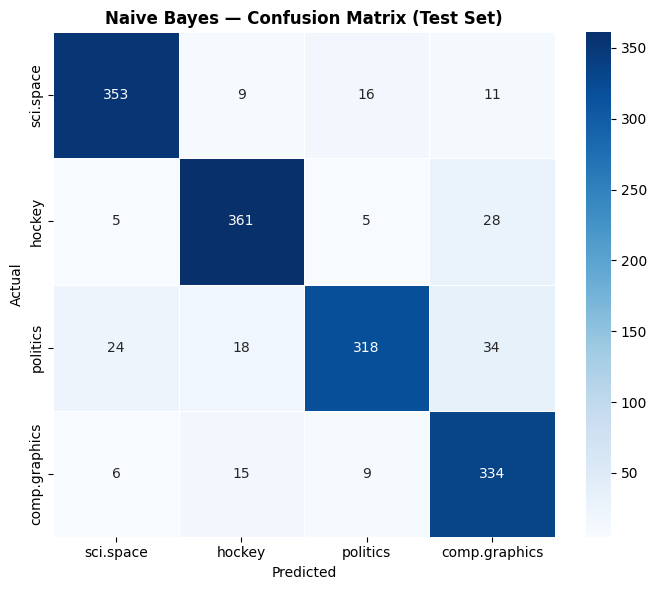

  sci.space           : 90.7%
  hockey              : 90.5%
  politics            : 80.7%
  comp.graphics       : 91.8%


In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
short_names = ['sci.space','hockey','politics','comp.graphics']
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=ax, linewidths=0.5)
ax.set_title('Naive Bayes — Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)
for name, acc in zip(short_names, per_class_acc):
    print(f'  {name:20s}: {acc:.1%}')

**Observation — Confusion matrix**

comp.graphics is the easiest class to separate at 91.8% accuracy — computing graphics posts use distinctive technical vocabulary (pixels, rendering, OpenGL). talk.politics.guns is the hardest at 80.7%: political posts share vocabulary with multiple categories (government, law, rights appear in hockey posts about CBA negotiations and space posts about NASA funding). sci.space and rec.sport.hockey are both above 90%.

### 4.3 Most Discriminative Words

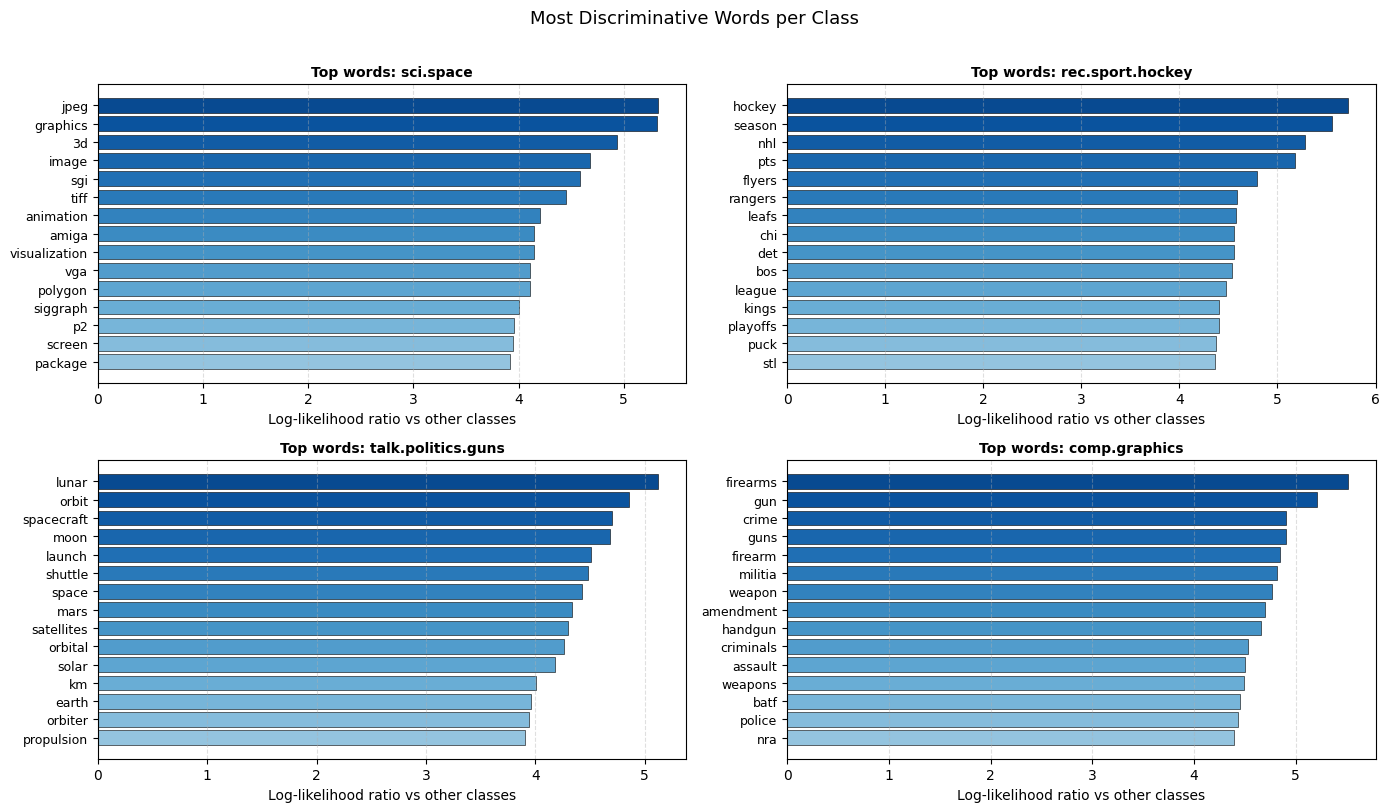

In [5]:
vocab = np.array(vectorizer.get_feature_names_out())
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (ax, name) in enumerate(zip(axes.flatten(), categories)):
    weights = log_ll[i] - np.mean([log_ll[j] for j in range(4) if j!=i], axis=0)
    top_idx = np.argsort(weights)[-15:][::-1]
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, 15))[::-1]
    ax.barh(range(15), weights[top_idx][::-1], color=colors[::-1], edgecolor='k', linewidth=0.4)
    ax.set_yticks(range(15))
    ax.set_yticklabels(vocab[top_idx][::-1], fontsize=9)
    ax.set_title(f'Top words: {name}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Log-likelihood ratio vs other classes')
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')
plt.suptitle('Most Discriminative Words per Class', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

**Observation — Discriminative words**

The top words per class should be highly category-specific: `shuttle`, `orbit`, `nasa` for space; `hockey`, `nhl`, `playoffs` for sport; `gun`, `firearms`, `amendment` for politics; `image`, `graphics`, `3d` for computing. These are the log-likelihood ratios that drive classification — a single high-signal word can shift the posterior decisively.

---
## 5. Results

| Class | Test accuracy |
|-------|--------------|
| sci.space | 90.7% |
| rec.sport.hockey | 90.5% |
| talk.politics.guns | 80.7% |
| comp.graphics | 91.8% |
| **Overall** | **88.36%** |

Multinomial Naïve Bayes achieves 88.36% test accuracy on 4-class text classification with a 5000-word vocabulary. The independence assumption (each word contributes independently to the class posterior) is clearly violated in real text, yet the model generalises well. The weakest class — politics at 80.7% — reflects genuine vocabulary overlap with other categories, not a modelling failure.

---
## 6. Limitations

- **Independence assumption**: words are not independent — "New" and "York" co-occur far more than chance. This causes probability estimates to be overconfident
- **Zero-probability problem**: without smoothing, a single unseen word drives the entire class probability to zero. Laplace smoothing fixes this but is not statistically principled
- **Bag of words loses order**: "man bites dog" and "dog bites man" are identical representations — the model cannot distinguish them
- **Rare words**: very infrequent words contribute noise; stop-word removal and minimum document-frequency thresholds are essential preprocessing steps
- **Feature engineering dependence**: the vocabulary size and which words to include significantly affect performance; this requires careful tuning